<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/DOFEN_TONIoT_updated_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# DOFEN settings
DEVICE       = "cuda"
N_EPOCHS     = 100
BATCH_SIZE   = 512
LR           = 1e-3
TREE_DEPTH   = 4
N_CONDITIONS = 128
N_TREES      = 64
N_FORESTS    = 8
D_HIDDEN     = 64
DROPOUT      = 0.1
PATIENCE     = 15

print("Config loaded.")

Config loaded.


In [2]:
# INSTALL

!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed.")

All packages installed.


In [3]:
# IMPORTS + DRIVE MOUNT + GPU CHECK

import os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    precision_score, recall_score,
    roc_auc_score, cohen_kappa_score,
    matthews_corrcoef, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

if not torch.cuda.is_available():
    print("WARNING: No GPU detected.")
    DEVICE = "cpu"
else:
    print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Device        : {DEVICE}")

Mounted at /content/drive
GPU confirmed : Tesla T4
VRAM          : 15.6 GB
Device        : cuda


In [4]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows   : {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows   : 211,043
Total columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS

drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features     : {X.shape[1]}")

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED, stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features     : 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

    return {"model": model_name, "accuracy": acc,
            "f1_macro": f1_macro, "f1_weighted": f1_weighted}

print("Evaluation helper ready.")

Evaluation helper ready.


In [7]:
# DOFEN MODEL DEFINITION


class ConditionGenerator(nn.Module):


    def __init__(self, n_features, n_conditions, d_hidden):
        super().__init__()
        # Per-feature condition generators
        self.nets = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, d_hidden),
                nn.LayerNorm(d_hidden),
                nn.ReLU(),
                nn.Linear(d_hidden, n_conditions),
                nn.Sigmoid(),  # soft conditions in [0, 1]
            )
            for _ in range(n_features)
        ])

    def forward(self, x):
        # x: (batch, n_features)
        # output: (batch, n_features, n_conditions)
        conditions = []
        for i, net in enumerate(self.nets):
            c = net(x[:, i:i+1])  # (batch, n_conditions)
            conditions.append(c)
        return torch.stack(conditions, dim=1)  # (batch, n_features, n_conditions)


class DOFEN(nn.Module):


    def __init__(self, n_features, num_classes, tree_depth=4,
                 n_conditions=128, n_trees=64, n_forests=8,
                 d_hidden=64, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        self.tree_depth = tree_depth
        self.n_trees = n_trees
        self.n_forests = n_forests
        self.num_classes = num_classes

        # Condition generator
        self.cond_gen = ConditionGenerator(n_features, n_conditions, d_hidden)


        self.register_buffer(
            'tree_feature_idx',
            torch.randint(0, n_features, (n_forests, n_trees, tree_depth))
        )
        # Random condition indices for each depth
        self.register_buffer(
            'tree_cond_idx',
            torch.randint(0, n_conditions, (n_forests, n_trees, tree_depth))
        )

        # Tree embeddings (learned per tree per forest)
        self.tree_embeddings = nn.Parameter(
            torch.randn(n_forests, n_trees, d_hidden) * 0.02
        )

        # Forest prediction sub-network
        self.forest_predictor = nn.Sequential(
            nn.Linear(d_hidden, d_hidden),
            nn.LayerNorm(d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, num_classes),
        )

    def forward(self, x):
        B = x.size(0)

        # Generate all soft conditions: (B, n_features, n_conditions)
        conditions = self.cond_gen(x)

        all_forest_logits = []

        for f_idx in range(self.n_forests):
            # Get feature and condition indices for this forest
            feat_idx = self.tree_feature_idx[f_idx]   # (n_trees, depth)
            cond_idx = self.tree_cond_idx[f_idx]       # (n_trees, depth)

            # Gather conditions for each tree at each depth
            # For each tree t, depth d: conditions[b, feat_idx[t,d], cond_idx[t,d]]
            tree_conditions = []
            for d in range(self.tree_depth):
                fi = feat_idx[:, d]   # (n_trees,)
                ci = cond_idx[:, d]   # (n_trees,)
                # Gather: (B, n_trees)
                c = conditions[:, fi, ci]
                tree_conditions.append(c)

            # rODT leaf = product of conditions across depths (soft AND)
            # (B, n_trees)
            leaf_values = torch.stack(tree_conditions, dim=-1).prod(dim=-1)

            # Weight by tree embeddings: (B, n_trees, d_hidden)
            tree_emb = self.tree_embeddings[f_idx].unsqueeze(0)  # (1, n_trees, d_hidden)
            weighted = leaf_values.unsqueeze(-1) * tree_emb       # (B, n_trees, d_hidden)

            # Aggregate: mean over trees in this forest
            forest_repr = weighted.mean(dim=1)  # (B, d_hidden)

            # Predict from this forest
            forest_logits = self.forest_predictor(forest_repr)  # (B, num_classes)
            all_forest_logits.append(forest_logits)

        # Bagging: average predictions across forests
        output = torch.stack(all_forest_logits, dim=0).mean(dim=0)  # (B, num_classes)
        return output

params = sum(p.numel() for p in DOFEN(
    n_features, num_classes, TREE_DEPTH, N_CONDITIONS,
    N_TREES, N_FORESTS, D_HIDDEN, DROPOUT).parameters())
print(f"DOFEN params: {params:,}")
print("Model class ready.")

DOFEN params: 183,498
Model class ready.


In [8]:
# DOFEN TRAINING

model = DOFEN(
    n_features=n_features,
    num_classes=num_classes,
    tree_depth=TREE_DEPTH,
    n_conditions=N_CONDITIONS,
    n_trees=N_TREES,
    n_forests=N_FORESTS,
    d_hidden=D_HIDDEN,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = nn.CrossEntropyLoss()

train_ds = TensorDataset(
    torch.tensor(X_train_s, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_ds = TensorDataset(
    torch.tensor(X_val_s, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long))
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Training DOFEN on TON-IoT...")
print(f"Config: depth={TREE_DEPTH}, trees={N_TREES}, forests={N_FORESTS}, "
      f"conditions={N_CONDITIONS}, lr={LR}")
print()

t0 = time.time()
best_val_f1 = 0
best_state  = None
no_improve  = 0

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()

    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            preds = model(xb.to(DEVICE)).argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    val_acc = accuracy_score(all_true, all_preds)
    val_f1  = f1_score(all_true, all_preds, average="macro", zero_division=0)

    print(f"  Epoch {epoch:03d}/{N_EPOCHS} | "
          f"Loss: {epoch_loss/len(train_dl):.4f} | "
          f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f"  Early stopping at epoch {epoch} (best Val F1: {best_val_f1:.4f})")
        break

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
model.eval()

train_time = time.time() - t0
print(f"\nBest Val F1: {best_val_f1:.4f}")
print(f"DOFEN training complete in {train_time:.1f}s ({train_time/60:.1f} min)")

Training DOFEN on TON-IoT...
Config: depth=4, trees=64, forests=8, conditions=128, lr=0.001

  Epoch 001/100 | Loss: 1.4796 | Val Acc: 0.5703 | Val F1: 0.4312
  Epoch 002/100 | Loss: 0.8536 | Val Acc: 0.7056 | Val F1: 0.5774
  Epoch 003/100 | Loss: 0.6398 | Val Acc: 0.7933 | Val F1: 0.6684
  Epoch 004/100 | Loss: 0.5207 | Val Acc: 0.8343 | Val F1: 0.7179
  Epoch 005/100 | Loss: 0.4381 | Val Acc: 0.8492 | Val F1: 0.7355
  Epoch 006/100 | Loss: 0.3753 | Val Acc: 0.8607 | Val F1: 0.7419
  Epoch 007/100 | Loss: 0.3405 | Val Acc: 0.8974 | Val F1: 0.8048
  Epoch 008/100 | Loss: 0.2985 | Val Acc: 0.9069 | Val F1: 0.8198
  Epoch 009/100 | Loss: 0.2786 | Val Acc: 0.9329 | Val F1: 0.8545
  Epoch 010/100 | Loss: 0.2569 | Val Acc: 0.9408 | Val F1: 0.8613
  Epoch 011/100 | Loss: 0.2384 | Val Acc: 0.9269 | Val F1: 0.8501
  Epoch 012/100 | Loss: 0.2273 | Val Acc: 0.9461 | Val F1: 0.8720
  Epoch 013/100 | Loss: 0.2181 | Val Acc: 0.9526 | Val F1: 0.8787
  Epoch 014/100 | Loss: 0.2095 | Val Acc: 0.9537 

Inference time : 0.74s for 42,209 samples
                (0.0175 ms per sample)

  DOFEN — Results
  Accuracy      : 0.9769
  F1 (macro)    : 0.9312
  F1 (weighted) : 0.9767

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.97      0.95      0.96      4000
         dos       0.99      0.97      0.98      4000
   injection       0.97      0.93      0.95      4000
        mitm       0.69      0.44      0.53       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.98      0.99      4000
  ransomware       0.99      1.00      0.99      4000
    scanning       0.98      0.98      0.98      4000
         xss       0.88      0.98      0.93      4000

    accuracy                           0.98     42209
   macro avg       0.95      0.92      0.93     42209
weighted avg       0.98      0.98      0.98     42209



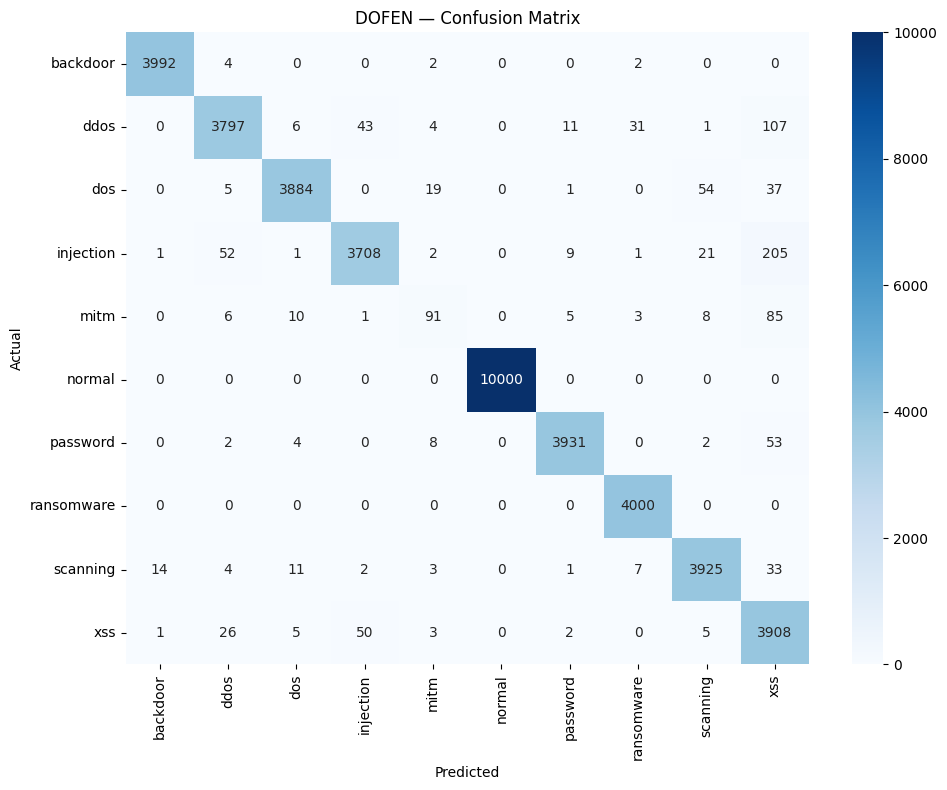

Saved: /content/drive/MyDrive/toniot_outputs/dofen_cm.png


In [9]:
# DOFEN TEST EVALUATION

test_ds = TensorDataset(
    torch.tensor(X_test_s, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long))
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

t0 = time.time()
all_preds, all_true, all_proba = [], [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb.to(DEVICE))
        proba  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())
        all_proba.append(proba)

infer_time = time.time() - t0
dofen_preds = np.array(all_preds)
dofen_proba = np.concatenate(all_proba, axis=0)

print(f"Inference time : {infer_time:.2f}s for {len(X_test_s):,} samples")
print(f"                ({infer_time / len(X_test_s) * 1000:.4f} ms per sample)")

dofen_results = evaluate(
    "DOFEN", y_test, dofen_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

  TABLE 1: DOFEN — Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.9769
Precision (macro) 0.9467
   Recall (macro) 0.9222
       F1 (macro) 0.9312
    F1 (weighted) 0.9767
              MCC 0.9736
    Cohen's Kappa 0.9736
  ROC-AUC (macro) 0.9984



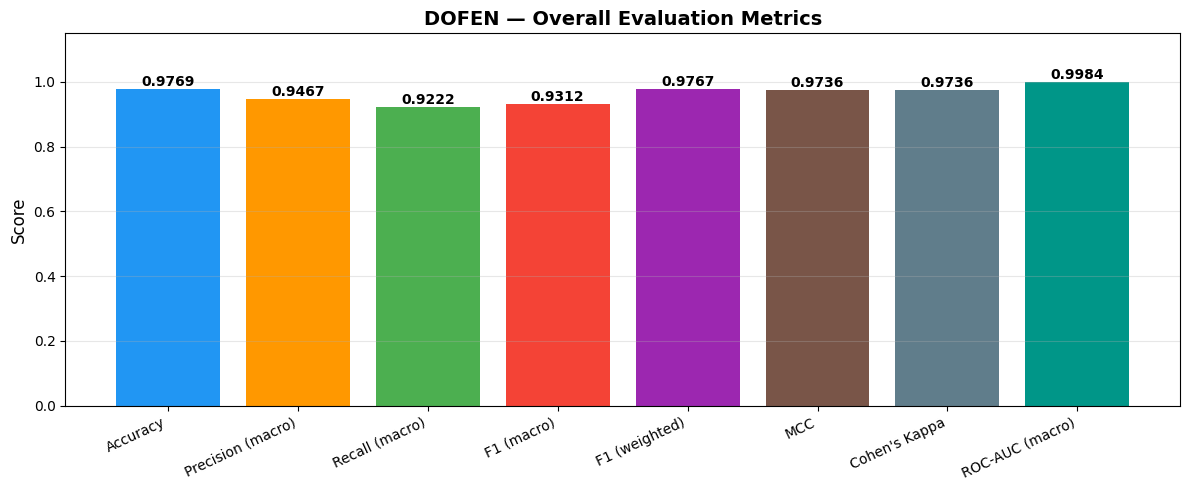

  TABLE 2: DOFEN — Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9960  0.9980    0.9970     4000
      ddos     0.9746  0.9492    0.9618     4000
       dos     0.9906  0.9710    0.9807     4000
 injection     0.9748  0.9270    0.9503     4000
      mitm     0.6894  0.4354    0.5337      209
    normal     1.0000  1.0000    1.0000    10000
  password     0.9927  0.9828    0.9877     4000
ransomware     0.9891  1.0000    0.9945     4000
  scanning     0.9773  0.9812    0.9793     4000
       xss     0.8826  0.9770    0.9274     4000



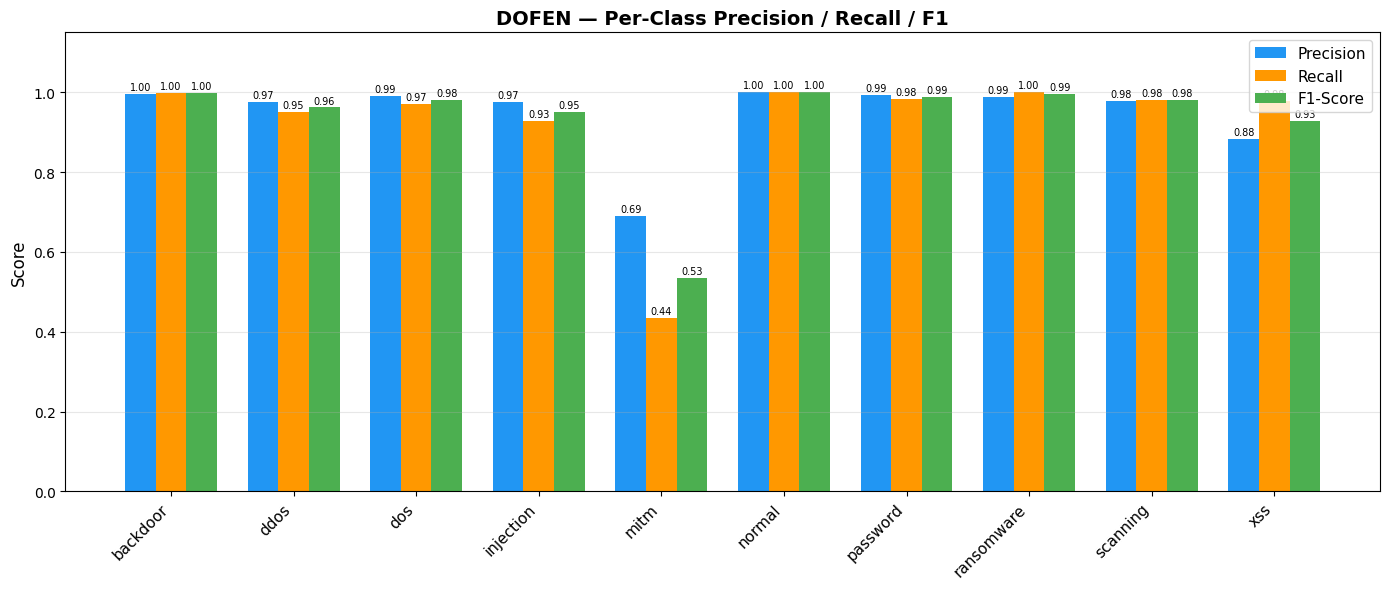

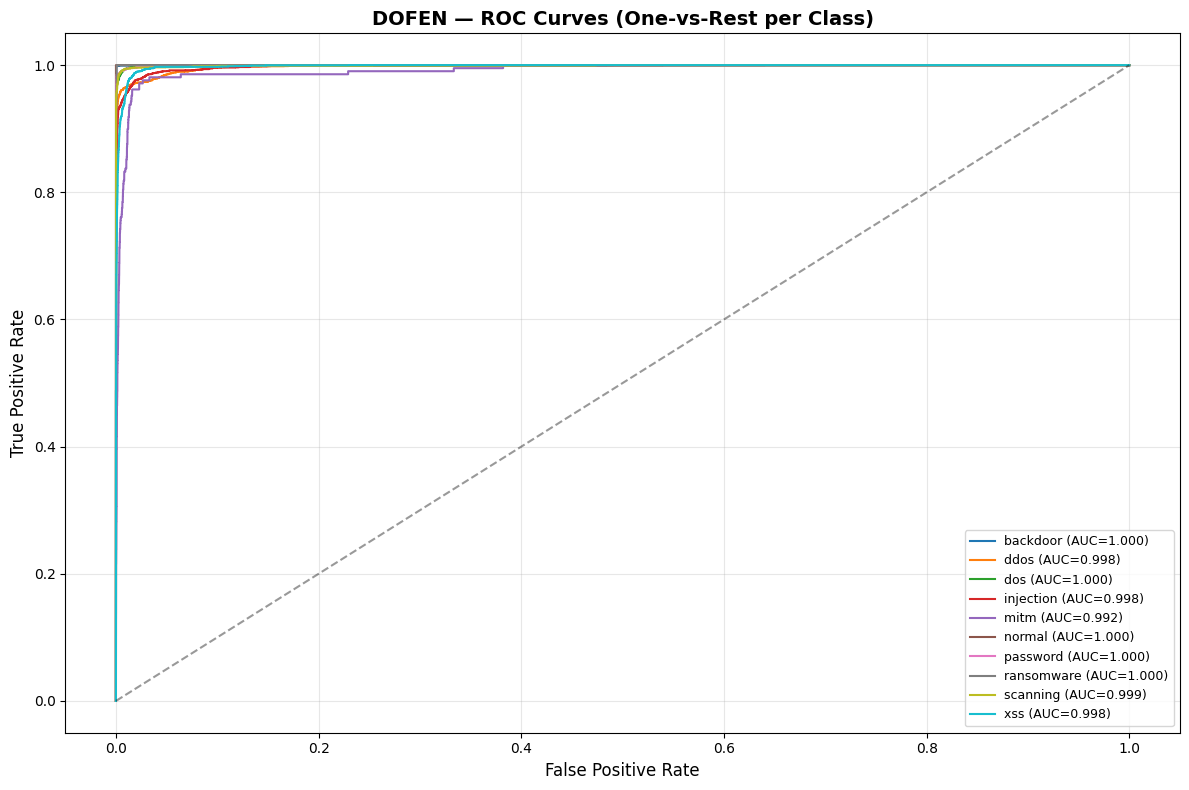

  TABLE 3: DOFEN — Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   0.9996
      ddos   0.9978
       dos   0.9998
 injection   0.9977
      mitm   0.9917
    normal   1.0000
  password   0.9996
ransomware   0.9999
  scanning   0.9992
       xss   0.9982

  Macro-average ROC-AUC: 0.9984

  TABLE 4: DOFEN — MCC & Cohen's Kappa
  MCC          : 0.9736 (Excellent)
  Cohen's Kappa: 0.9736 (Almost Perfect)


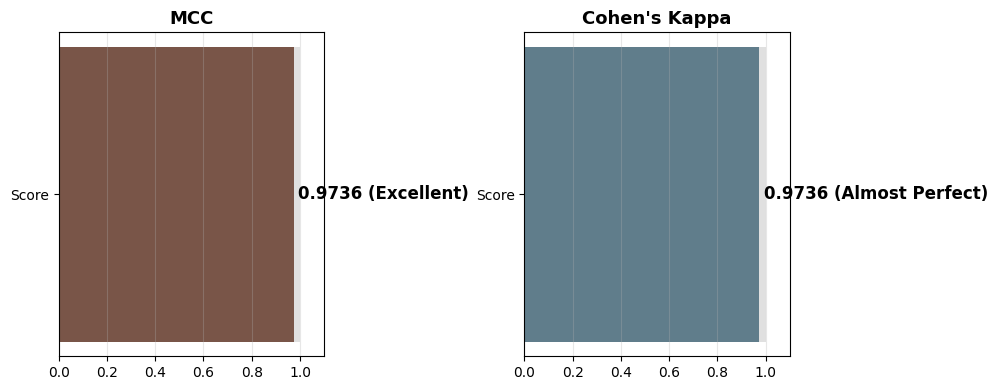

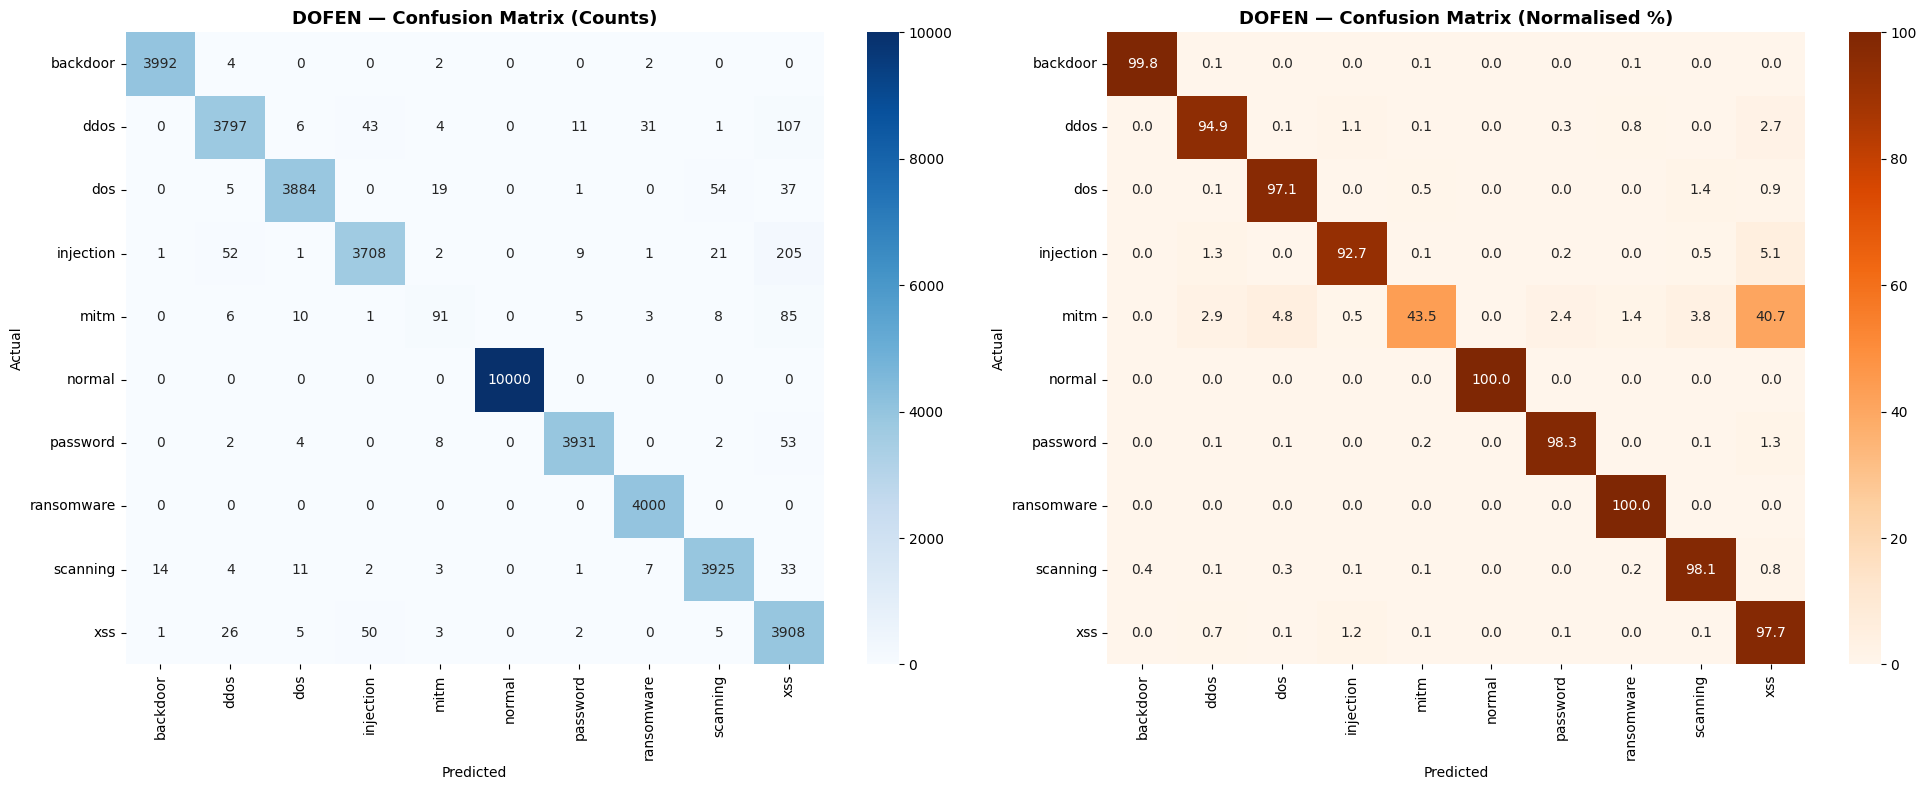


All visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [10]:
# DOFEN — COMPREHENSIVE METRICS WITH TABLES & VISUALISATIONS

y_true = y_test
y_pred = dofen_preds
y_prob = dofen_proba
label_names = list(le.classes_)


# 1. MACRO METRICS SUMMARY TABLE + BAR CHART


acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

try:
    roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
except:
    roc_auc = None

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: DOFEN — Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("DOFEN — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "dofen_macro_metrics.png"), dpi=150); plt.show()


# 2. PER-CLASS PRECISION, RECALL, F1 TABLE + CHART

prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names, "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4), "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})
print("=" * 60)
print("  TABLE 2: DOFEN — Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False)); print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names)); w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01: ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("DOFEN — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "dofen_perclass_prf.png"), dpi=150); plt.show()


# 3. ROC-AUC PER CLASS — TABLE + CURVES

y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
auc_per_class = []
fig, ax = plt.subplots(figsize=(12, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    auc_per_class.append(class_auc)
    ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate", fontsize=12); ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("DOFEN — ROC Curves (One-vs-Rest per Class)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "dofen_roc_curves.png"), dpi=150); plt.show()

roc_df = pd.DataFrame({"Class": label_names, "ROC-AUC": np.round(auc_per_class, 4)})
print("=" * 60)
print("  TABLE 3: DOFEN — Per-Class ROC-AUC")
print("=" * 60)
print(roc_df.to_string(index=False))
if roc_auc: print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")


# 4. MCC & COHEN'S KAPPA

def interpret_mcc(v):
    if v >= 0.9: return "Excellent"
    if v >= 0.7: return "Strong"
    if v >= 0.5: return "Moderate"
    if v >= 0.3: return "Weak"
    return "Poor"
def interpret_kappa(v):
    if v >= 0.81: return "Almost Perfect"
    if v >= 0.61: return "Substantial"
    if v >= 0.41: return "Moderate"
    if v >= 0.21: return "Fair"
    return "Slight/Poor"

print(); print("=" * 60)
print("  TABLE 4: DOFEN — MCC & Cohen's Kappa")
print("=" * 60)
print(f"  MCC          : {mcc:.4f} ({interpret_mcc(mcc)})")
print(f"  Cohen's Kappa: {kappa:.4f} ({interpret_kappa(kappa)})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mn, val, interp, col in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B")]:
    ax.barh(["Score"], [val], color=col, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(val + 0.02, 0, f"{val:.4f} ({interp})", va="center", fontsize=12, fontweight="bold")
    ax.set_title(mn, fontsize=13, fontweight="bold"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "dofen_mcc_kappa.png"), dpi=150); plt.show()


# 5. DUAL CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("DOFEN — Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges", xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("DOFEN — Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "dofen_cm_dual.png"), dpi=150); plt.show()

print("\nAll visualisations saved to:", DRIVE_OUT_DIR)

In [11]:
# OVERFITTING / UNDERFITTING DIAGNOSIS

all_preds_tr = []
model.eval()
with torch.no_grad():
    for xb, yb in train_dl:
        preds = model(xb.to(DEVICE)).argmax(dim=-1).cpu().numpy()
        all_preds_tr.extend(preds)

dofen_train_acc = accuracy_score(y_train, all_preds_tr)
dofen_train_f1  = f1_score(y_train, all_preds_tr, average="macro", zero_division=0)

print("=" * 50)
print("DOFEN — Train vs Test Diagnosis")
print("=" * 50)
print(f"  Train Acc    : {dofen_train_acc:.4f}")
print(f"  Test  Acc    : {dofen_results['accuracy']:.4f}")
print(f"  Train F1     : {dofen_train_f1:.4f}")
print(f"  Test  F1     : {dofen_results['f1_macro']:.4f}")
print()

acc_gap = dofen_train_acc - dofen_results['accuracy']
if acc_gap > 0.05:
    print(f"  Warning: Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif dofen_results['accuracy'] < 0.80:
    print("  Warning: Low test accuracy — possible underfitting")
else:
    print(f"  Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {train_time:.1f}s")
print(f"  Inference time: {infer_time:.2f}s ({len(X_test_s):,} samples)")

DOFEN — Train vs Test Diagnosis
  Train Acc    : 0.1289
  Test  Acc    : 0.9769
  Train F1     : 0.1007
  Test  F1     : 0.9312

  Generalisation gap: -0.8481 — model generalises well

  Training time : 973.3s
  Inference time: 0.74s (42,209 samples)


In [12]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"           : "DOFEN",
    "paper"           : "NeurIPS 2024 — Chen et al.",
    "dataset"         : "TON-IoT Network",
    "train_samples"   : len(X_train),
    "test_samples"    : len(X_test_s),
    "n_features"      : n_features,
    "n_classes"       : num_classes,
    "accuracy"        : acc,
    "f1_macro"        : f1_macro,
    "f1_weighted"     : f1_weighted,
    "precision_macro" : prec_macro,
    "recall_macro"    : rec_macro,
    "mcc"             : mcc,
    "cohen_kappa"     : kappa,
    "roc_auc_macro"   : roc_auc,
    "train_acc"       : dofen_train_acc,
    "train_f1"        : dofen_train_f1,
    "train_time_s"    : round(train_time, 2),
    "infer_time_s"    : round(infer_time, 4),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "dofen_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                          0
model                                 DOFEN
paper            NeurIPS 2024 — Chen et al.
dataset                     TON-IoT Network
train_samples                        147729
test_samples                          42209
n_features                               17
n_classes                                10
accuracy                           0.976948
f1_macro                           0.931234
f1_weighted                        0.976711
precision_macro                    0.946702
recall_macro                       0.922166
mcc                                0.973637
cohen_kappa                        0.973559
roc_auc_macro                      0.998355
train_acc                          0.128885
train_f1                           0.100719
train_time_s                         973.28
infer_time_s                         0.7402

Results saved to: /content/drive/MyDrive/toniot_outputs/dofen_toniot_results.csv
